### Load and Preprocess the Dataset

In [1]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import os
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Define paths to the dataset directories
dataset_path = '/content/drive/MyDrive/leaf/train/tomato'

In [4]:
# Split the dataset into training and validation sets
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,  # Use 20% of the data for validation
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [5]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 92 images belonging to 3 classes.
Found 22 images belonging to 3 classes.


In [6]:
print(train_generator.num_classes)

3


### Model Training

In [7]:
plant_list = ['Not_Detected', 'Tomato_healthy', 'Tomato_unhealthy']

# Model setup
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(3, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)

for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

initial_epochs = 8
history = model.fit(
    train_generator,
    epochs=initial_epochs,
    validation_data=validation_generator
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 52s 16s/step - accuracy: 0.2936 - loss: 3.7864 - val_accuracy: 0.5000 - val_loss: 2.0469
Epoch 2/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 598ms/step - accuracy: 0.4673 - loss: 1.6974 - val_accuracy: 0.3182 - val_loss: 2.5569
Epoch 3/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 600ms/step - accuracy: 0.5121 - loss: 1.2395 - val_accuracy: 0.4545 - val_loss: 0.8849
Epoch 4/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 584ms/step - accuracy: 0.6855 - loss: 0.6434 - val_accuracy: 0.6364 - val_loss: 1.0273
Epoch 5/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 570ms/step - accuracy: 0.6869 - loss: 0.7407 - val_accuracy: 0.4545 - val_loss: 1.0063
Epoch 6/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 569ms/step - accuracy: 0.8067 - loss: 0.4854 - val_accuracy: 0.4545 - val_loss: 1.4239
Epoch 7/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 574ms/step - accuracy: 0.7103 - loss: 0.6121 - val_accuracy: 0.5000 - val_loss: 1.4983
Epoch 8/8
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 619ms/step - accuracy: 0.8398 - loss: 0.4601 - val_accuracy: 0.4091 - val_loss: 1.0398


In [8]:
model.save_weights('/content/drive/MyDrive/leaf/model.weights.h5')

In [ ]:
# !pip install tflite_runtime

# import tensorflow as tf

# converter = tf.lite.TFLiteConverter.from_keras_model(model)
# converter.optimizations = [tf.lite.Optimize.DEFAULT]
# converter.target_spec.supported_ops = [
#     tf.lite.OpsSet.TFLITE_BUILTINS,  # TFLite ops only
# ]
# converter._experimental_disable_per_channel = True  # Critical for ARM
# converter.target_spec.supported_types = [tf.float32]  # Avoid int8

# tflite_model = converter.convert()
# with open('plant_model_fixed.tflite', 'wb') as f:
#     f.write(tflite_model)

# interpreter = tf.lite.Interpreter(model_path='plant_model_fixed.tflite')
# interpreter.allocate_tensors()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 25.2 MB/s eta 0:00:00


### Step 5: Evaluate the Model

In [ ]:
# Evaluate the model
loss, accuracy = model.evaluate(validation_generator)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

### Step 6: Visualize Training Progress

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'] + history.history['accuracy'])
plt.plot(history.history['val_accuracy'] + history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
# Plot training & validation loss values
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'] + history.history['loss'])
plt.plot(history.history['val_loss'] + history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

## Provide inputs

Load the model

In [9]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [11]:
# Redefine the model architecture
base_model = MobileNetV2(weights=None, include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(3, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)

# Load the weights
model.load_weights('/content/drive/MyDrive/leaf/model.weights.h5')

Upload the Image

In [12]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np

In [13]:
# Upload an image
uploaded = files.upload()

Saving img_20250422_152534.jpg to img_20250422_152534.jpg


In [14]:
# Load the uploaded image
for filename in uploaded.keys():
    img_path = filename
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Normalize the image

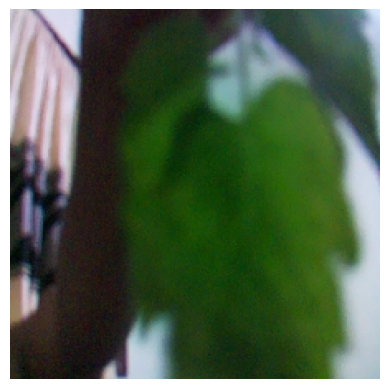

In [15]:
# Display the image
plt.imshow(img_array[0])
plt.axis('off')
plt.show()

In [16]:
print(list(train_generator.class_indices.keys()))

['Not_detected', 'Tomato_healthy', 'Tomato_unhealthy']


Make a Prediction

In [17]:
# Make a prediction
predictions = model.predict(img_array)

# Get the class label with the highest predicted probability
predicted_class_index = np.argmax(predictions[0])
class_labels = list(train_generator.class_indices.keys())
predicted_class_label = class_labels[predicted_class_index]

print(f"Predicted class: {predicted_class_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted class: Tomato_healthy
